<a href="https://colab.research.google.com/github/girixyz/aqi-prediction/blob/main/AQI_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#loading dataset
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/sem6/city_day.csv')
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [ ]:
df.count()

,0
City,29531
Date,29531
PM2.5,24933
PM10,18391
NO,25949
NO2,25946
NOx,25346
NH3,19203
CO,27472
SO2,25677


In [ ]:
# extracting year, month, date and day into a single datetime (date)
df['Date'] = pd.to_datetime(df['Date'])
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day']   = df['Date'].dt.day

# handling missing values for AQI
df.dropna(subset=['AQI'], inplace=True)
print("Rows after dropping missing aqi values:", df.shape[0])

# handling missing values of the pollutants by replacing their values with column mean
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3',
              'CO','SO2','O3','Benzene','Toluene','Xylene']

for col in pollutants:
    df[col].fillna(df[col].mean(), inplace=True)

# encoding helps in converting categorial data into numerical data
le = LabelEncoder()
df['City_encoded'] = le.fit_transform(df['City'])

# dropping "AQI_Bucket" because it is a categorial label (good, satisfactory, poor etc)
df.drop(columns=['AQI_Bucket'], inplace=True, errors='ignore')

print("\nMissing values after cleaning:\n", df.isnull().sum())
print("\nCleaned Shape:", df.shape)

Rows after dropping missing aqi values: 24850

Missing values after cleaning:
 City            0
Date            0
PM2.5           0
PM10            0
NO              0
NO2             0
NOx             0
NH3             0
CO              0
SO2             0
O3              0
Benzene         0
Toluene         0
Xylene          0
AQI             0
Year            0
Month           0
Day             0
City_encoded    0
dtype: int64

Cleaned Shape: (24850, 19)


/tmp/ipykernel_1179/2833963100.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
# calculating descriptive stats, skewness and kurtosis.
print("Descriptive Statistics:")
print(df[['PM2.5','PM10','NO2','CO','AQI']].describe())

print("\nSkewness:")
print(df[['PM2.5','PM10','NO2','CO','AQI']].skew())

print("\nKurtosis: ")
print(df[['PM2.5','PM10','NO2','CO','AQI']].kurt())

Descriptive Statistics:
              PM2.5          PM10           NO2            CO           AQI
count  24850.000000  24850.000000  24850.000000  24850.000000  24850.000000
mean      67.476613    118.454435     28.978391      2.345267    166.463581
std       62.208948     75.660357     24.432532      7.011570    140.696585
min        0.040000      0.030000      0.010000      0.000000     13.000000
25%       29.560000     71.780000     12.090000      0.590000     81.000000
50%       50.165000    118.454435     22.535000      0.950000    118.000000
75%       79.507500    122.957500     37.910000      1.530000    208.000000
max      914.940000    917.080000    362.210000    175.810000   2049.000000

Skewness:
PM2.5    3.001942
PM10     2.285684
NO2      2.455656
CO       8.707678
AQI      3.396757
dtype: float64

Kurtosis: 
PM2.5     15.381058
PM10       8.836271
NO2       11.225098
CO       105.209409
AQI       21.423727
dtype: float64


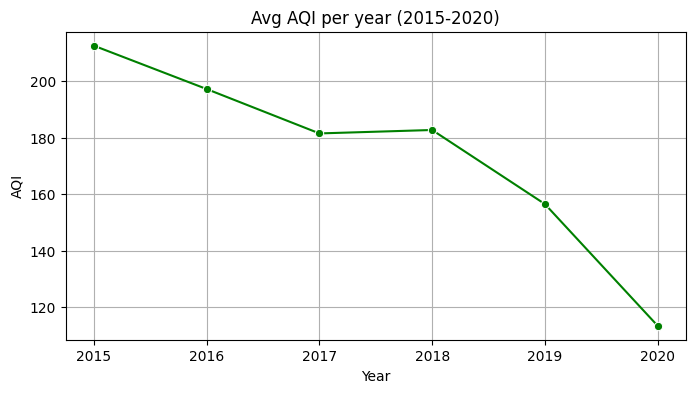

In [ ]:
# visualization of current dataset (2015-2020)
yearly_avg = df.groupby('Year')['AQI'].mean().reset_index()
plt.figure(figsize=(8,4))
sns.lineplot(data=yearly_avg, x='Year', y='AQI', marker='o', color='green')
plt.title('Avg AQI per year (2015-2020)')
plt.xlabel('Year')
plt.ylabel('AQI')
plt.grid(True)
plt.show()

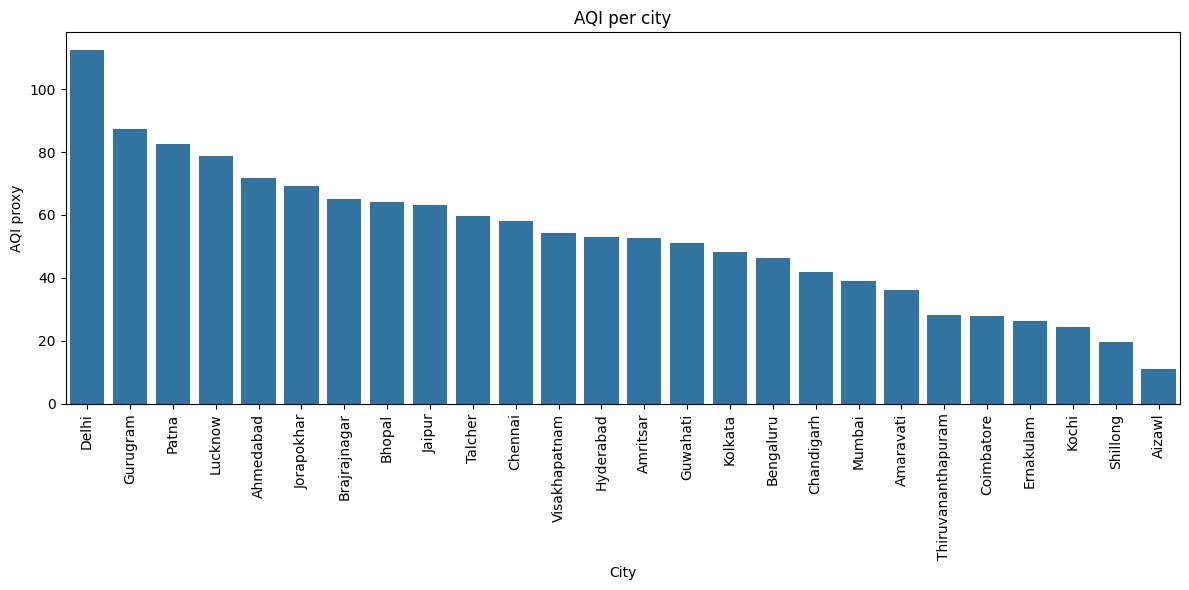

In [ ]:
# instead of using raw AQI data which had inconsistencies, we use a proxy AQI data (predicted AQI calculated from pollutants)
# it contains the weighted pollutants (i.e PM2.5 has highest impact, then PM10) and plotting their graph.

df['AQI_proxy'] = (
    df['PM2.5'] * 0.4 +
    df['PM10'] * 0.3 +
    df['NO2'] * 0.1 +
    df['CO'] * 0.1 +
    df['O3'] * 0.1
)
city_avg = df.groupby('City')['AQI_proxy'].median().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=city_avg.index, y=city_avg.values)

plt.xticks(rotation=90)
plt.title("AQI per city")
plt.xlabel("City")
plt.ylabel("AQI proxy")

plt.tight_layout()
plt.show()

In [ ]:
# Selecting features to use in regression
features = ['PM2.5','PM10','NO2','CO','SO2','O3',
            'NH3','Benzene','City_encoded','Year','Month']

X = df[features]
y = df['AQI']

# splitting samples into 80 (training samples) : 20 (testing samples)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing  samples:", X_test.shape[0])

Training samples: 19880
Testing  samples: 4970


In [ ]:
19880+4970

24850

In [ ]:
# training the model
model = LinearRegression()
model.fit(X_train, y_train)

print("completed model training.")
print("\nIntercept (β₀):", round(model.intercept_, 4))

# Feature coefficients
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature Coefficients:")
print(coeff_df.to_string(index=False))

completed model training.

Intercept (β₀): 2233.6152

Feature Coefficients:
     Feature  Coefficient
          CO    11.681042
       PM2.5     1.110264
         SO2     0.688751
        PM10     0.289754
         NO2     0.264703
          O3     0.195050
City_encoded     0.032131
     Benzene    -0.000523
         NH3    -0.078935
       Month    -0.405638
        Year    -1.101938


In [ ]:
#model evaluation using mae, mse, rmse and r^2 scores
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation:
MAE  : 31.15
MSE  : 3495.40
RMSE : 59.12
R²   : 0.8091


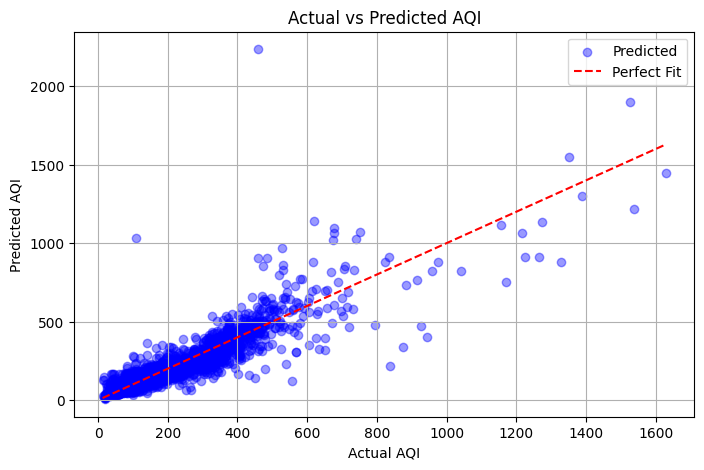

In [ ]:
# Comparing actual vs predicted AQI using scatterplot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI')
plt.legend()
plt.grid(True)
plt.show()

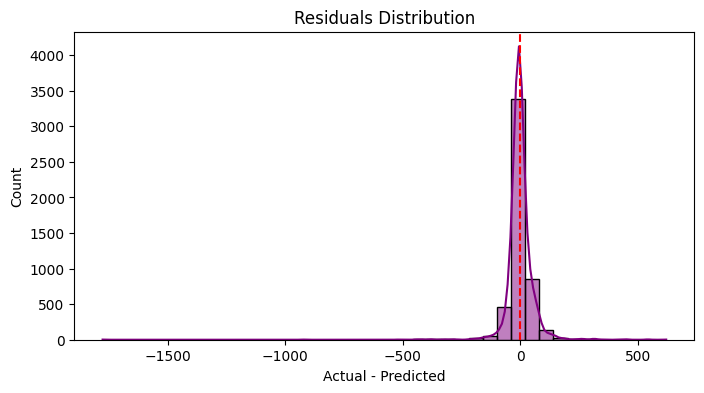

In [ ]:
# plotting residual distribution using histogram (shows how prediction errors are spread)
residuals = y_test - y_pred

plt.figure(figsize=(8,4))
sns.histplot(residuals, bins=40, kde=True, color='purple')
plt.title('Residuals Distribution')
plt.xlabel('Actual - Predicted')
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [ ]:
# avg pollutant values per month
monthly_avg = df.groupby('Month')[features[:-2]].mean()
print("Monthly pollutant avg:")
monthly_avg

Monthly pollutant avg:


,PM2.5,PM10,NO2,CO,SO2,O3,NH3,Benzene,City_encoded
Month,,,,,,,,,
1,107.327078,154.900646,37.957841,2.771941,16.584885,38.270851,29.488026,4.244312,12.945820
2,82.592755,140.978834,34.918037,2.985376,16.642872,38.448971,25.063906,3.955916,12.723292
3,63.041383,116.967459,28.069895,2.179902,15.593505,38.257088,22.753492,5.547933,12.520842
4,53.022873,109.443558,24.485000,1.805009,13.939907,39.125647,21.677642,2.423331,12.386057
5,50.995660,108.907710,22.870478,1.501742,14.110233,39.770791,21.481531,2.916211,12.387004
6,43.851727,93.841530,22.472466,1.661106,11.536670,33.595532,20.069949,2.725884,12.222270
7,38.232823,87.911066,21.686177,2.410920,11.753666,24.364436,21.955424,2.073678,12.562092
8,35.064525,87.407039,20.887558,2.697782,12.139088,23.501138,20.594982,2.866413,12.631757
9,37.940801,87.522747,23.970610,2.160090,11.031193,26.716903,20.030463,2.266097,12.683552


In [ ]:
#generating synthetic data for prediction
np.random.seed(42)
future_rows = []

for year in [2021, 2022]:
    for month in range(1, 13):
        for city_code in df['City_encoded'].unique():

            # Get monthly baseline pollutant values
            base = monthly_avg.loc[month]

            row = {
                # Add ±5% random noise to each pollutant
                'PM2.5'       : base['PM2.5']   * np.random.uniform(0.95, 1.05),
                'PM10'        : base['PM10']    * np.random.uniform(0.95, 1.05),
                'NO2'         : base['NO2']     * np.random.uniform(0.95, 1.05),
                'CO'          : base['CO']      * np.random.uniform(0.95, 1.05),
                'SO2'         : base['SO2']     * np.random.uniform(0.95, 1.05),
                'O3'          : base['O3']      * np.random.uniform(0.95, 1.05),
                'NH3'         : base['NH3']     * np.random.uniform(0.95, 1.05),
                'Benzene'     : base['Benzene'] * np.random.uniform(0.95, 1.05),
                'City_encoded': city_code,
                'Year'        : year,
                'Month'       : month
            }
            future_rows.append(row)

future_df = pd.DataFrame(future_rows)

# Predict AQI
future_df['Predicted_AQI'] = model.predict(future_df[features])

print(f"Total future rows generated: {future_df.shape[0]}")
print(future_df[['Year','Month','City_encoded','Predicted_AQI']].head(10))

Total future rows generated: 624
   Year  Month  City_encoded  Predicted_AQI
0  2021      1             0     229.756143
1  2021      1             1     232.672488
2  2021      1             2     226.227995
3  2021      1             3     229.561839
4  2021      1             4     227.082969
5  2021      1             5     225.604868
6  2021      1             6     230.694062
7  2021      1             7     221.782568
8  2021      1             8     227.492722
9  2021      1             9     226.009669


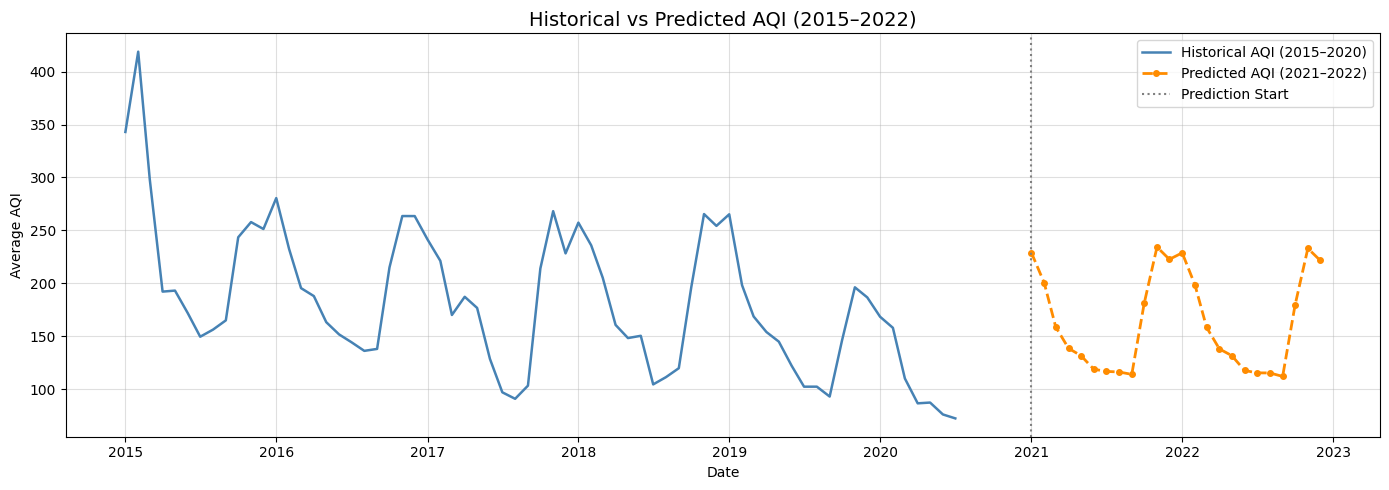

In [ ]:
# future monthly avg across all cities
future_monthly = (
    future_df.groupby(['Year', 'Month'])['Predicted_AQI']
    .mean()
    .reset_index()
)
future_monthly['Date'] = pd.to_datetime(
    future_monthly[['Year', 'Month']].assign(Day=1)
)

# historical monthly avg for comparison
hist_monthly = (
    df.groupby(['Year', 'Month'])['AQI']
    .mean()
    .reset_index()
)
hist_monthly['Date'] = pd.to_datetime(
    hist_monthly[['Year', 'Month']].assign(Day=1)
)

# plotting both historical and future graph together using line plot
plt.figure(figsize=(14, 5))

plt.plot(hist_monthly['Date'], hist_monthly['AQI'],
         color='steelblue', linewidth=1.8, label='Historical AQI (2015–2020)')

plt.plot(future_monthly['Date'], future_monthly['Predicted_AQI'],
         color='darkorange', linewidth=2, linestyle='--',
         marker='o', markersize=4, label='Predicted AQI (2021–2022)')

# Divider line
plt.axvline(pd.Timestamp('2021-01-01'), color='gray',
            linestyle=':', linewidth=1.5, label='Prediction Start')

plt.title('Historical vs Predicted AQI (2015–2022)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

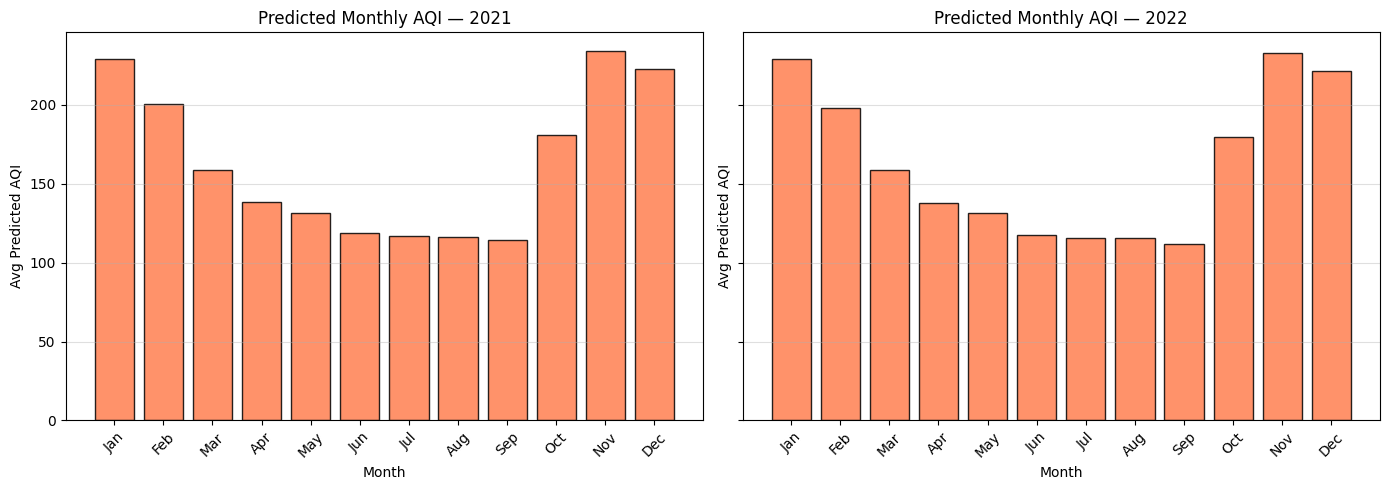

In [ ]:
# plotting predicted AQI vs Month for 2021 and 2022
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, year in zip(axes, [2021, 2022]):
    subset = future_df[future_df['Year'] == year]
    monthly_pred = subset.groupby('Month')['Predicted_AQI'].mean()

    ax.bar(monthly_pred.index, monthly_pred.values,
           color='coral', edgecolor='black', alpha=0.85)
    ax.set_title(f'Predicted Monthly AQI — {year}', fontsize=12)
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg Predicted AQI')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()